## **Conjunto de datos de clasificación de imágenes pequeñas CIFAR10**

### **Efrain Alvarez**

Se sabe que el conjunto de datos CIFAR-10 contiene un pequeño porcentaje de muestras mal etiquetadas, lo cual es inherente al conjunto de datos original. Este ruido en las etiquetas puede afectar el entrenamiento y la evaluación. Para obtener más detalles, consulte las discusiones en la literatura de investigación sobre la calidad de las etiquetas de CIFAR-10.

## Importaciones

Todas las librerías necesarias para el proyecto completo.
Se importan al inicio para tener una visión clara de las dependencias.

In [1]:
# ============================================================
# IMPORTACIONES
# ============================================================

# --- 1. Sistema y utilidades ---
import os
import random
import warnings
import cv2

# --- 2. Numéricas ---
import numpy as np

# --- 3. Visualización ---
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# --- 4. Deep Learning — TensorFlow / Keras ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dropout, Dense,
                                     Resizing, Input, RandomFlip,
                                     RandomRotation, RandomZoom)



# --- 5. Métricas de evaluación ---
from sklearn.metrics import classification_report, confusion_matrix

## Carga del Dataset CIFAR-10

Se descarga y divide automáticamente el dataset en conjuntos de
entrenamiento y prueba usando la utilidad integrada de Keras.

Se imprimen las dimensiones, tipos de dato y rango de píxeles para
verificar que los datos llegaron correctamente antes de cualquier
preprocesamiento. CIFAR-10 contiene **60,000 imágenes** de 32×32
píxeles en RGB, distribuidas en 50,000 para entrenamiento y 10,000
para prueba, con valores de píxel en el rango **[0 - 255]**.

In [2]:
# ============================================================
# CARGA DEL DATASET
# ============================================================

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print(f"X_train : {X_train.shape}  dtype: {X_train.dtype}")
print(f"y_train : {y_train.shape}  dtype: {y_train.dtype}")
print(f"X_test  : {X_test.shape}   dtype: {X_test.dtype}")
print(f"y_test  : {y_test.shape}   dtype: {y_test.dtype}")
print(f"Rango de pixeles : [{X_train.min()} - {X_train.max()}]")
print(f"Total imagenes   : {len(X_train) + len(X_test):,}")

X_train : (50000, 32, 32, 3)  dtype: uint8
y_train : (50000, 1)  dtype: uint8
X_test  : (10000, 32, 32, 3)   dtype: uint8
y_test  : (10000, 1)   dtype: uint8
Rango de pixeles : [0 - 255]
Total imagenes   : 60,000


## Visualización de las primeras 30 imágenes

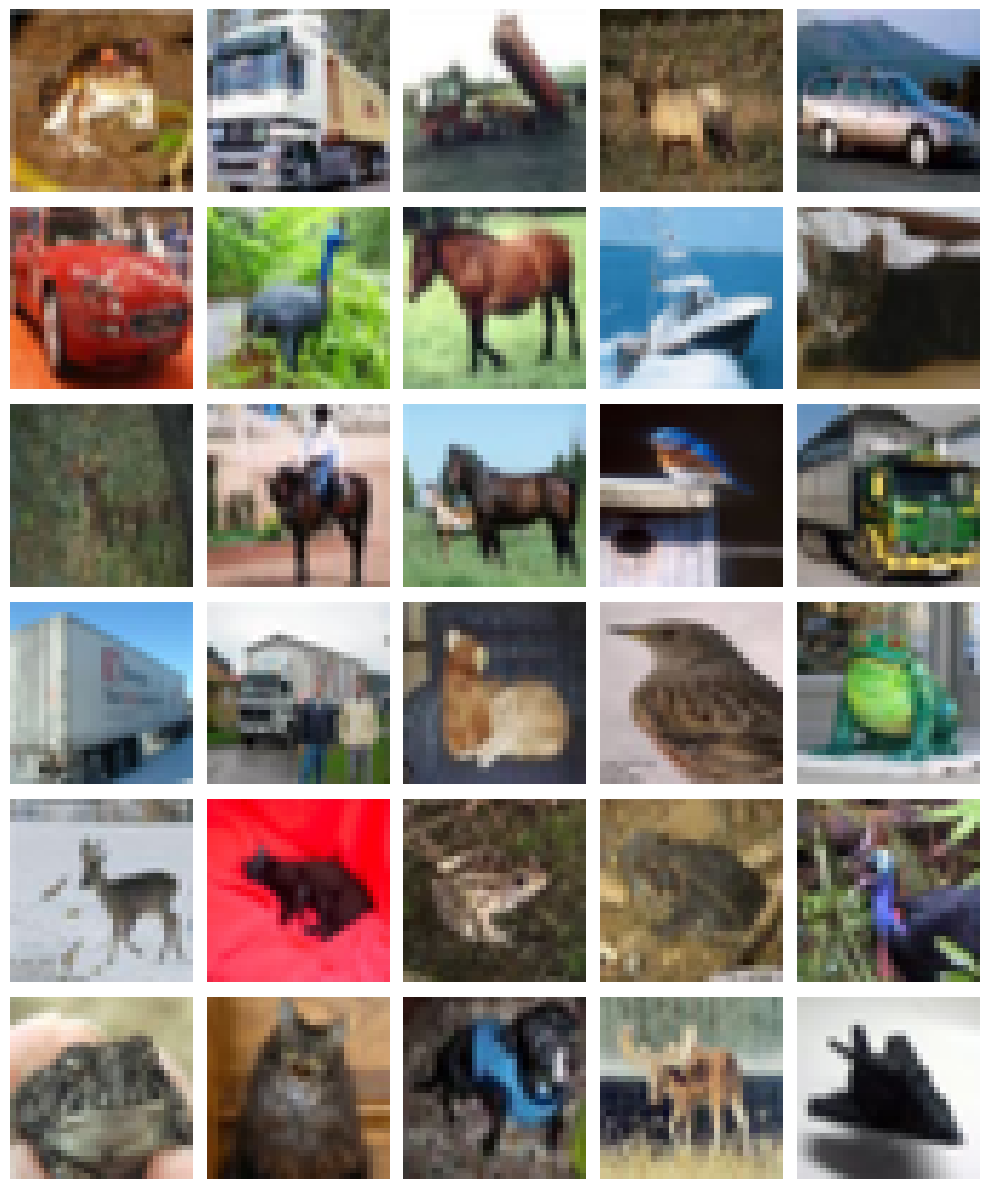

In [3]:
# Cuadrícula de 6 filas x 5 columnas para mostrar 30 imágenes
fig, axes = plt.subplots(6, 5, figsize=(10, 12))

# Recorrer cada celda de la cuadrícula
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])                          # Mostrar la imagen en color RGB
    ax.axis('off')                                 # Ocultar ejes

plt.tight_layout()
plt.show()

## Clases únicas en el dataset

In [4]:
# Clases únicas presentes en el conjunto de entrenamiento
print(np.unique(y_train))

# Cantidad de clases únicas
print(f"Numero de clases unicas: {len(np.unique(y_train))}")

[0 1 2 3 4 5 6 7 8 9]
Numero de clases unicas: 10


## Asignación de nombres de clases

In [5]:
# Nombres de las 10 clases en el orden que usa CIFAR-10 (índice 0-9)
CLASS_NAMES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

## Construcción del modelo con Transfer Learning (ResNet50)

Se define la arquitectura completa del modelo usando **ResNet50** preentrenada
en ImageNet como backbone, adaptada para clasificar las 10 categorías de CIFAR-10.

El pipeline interno de la función tiene 5 etapas:

1. **Data Augmentation** — volteo horizontal, rotación y zoom aleatorios para
   regularizar y mejorar la generalización sin aumentar el dataset.
2. **Resize** — las imágenes de 32×32 se escalan a 224×224, resolución esperada
   por ResNet50.
3. **Preprocesamiento ResNet50** — normalización de píxeles con `preprocess_input`
   para que coincidan con la distribución usada durante el preentrenamiento en ImageNet.
4. **Base congelada** — `base.trainable = False` congela todos los pesos de ResNet50;
   solo actúa como extractor de características en esta fase.
5. **Cabeza clasificadora** — `GlobalAveragePooling2D` reduce el mapa de características,
   `Dropout(0.5)` regulariza, y `Dense(10, softmax)` produce las probabilidades finales.

Se compila con `Adam(lr=1e-4)` y `sparse_categorical_crossentropy` (etiquetas como
enteros, no one-hot).

In [6]:
def construir_modelo(input_shape=(32, 32, 3), num_classes=10):

    inputs = Input(shape=input_shape)

    # 1️⃣ Data Augmentation
    x = RandomFlip("horizontal")(inputs)
    x = RandomRotation(0.1)(x)
    x = RandomZoom(0.1)(x)

    # 2️⃣ Resize (sobre x, no inputs)
    x = Resizing(224, 224)(x)

    # 3️⃣ Preprocesamiento correcto para ResNet50
    x = tf.keras.layers.Lambda(preprocess_input)(x)

    # 4️⃣ Base model
    base = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base.trainable = False

    x = base(x, training=False)

    # 5️⃣ Clasificador
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model = construir_modelo()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Entrenamiento inicial (Transfer Learning)

Fase de calentamiento: se congela la base ResNet50 y solo se entrena
la cabeza clasificadora durante 5 épocas con un learning rate estándar.
Esto permite que las capas nuevas aprendan sin destruir los pesos preentrenados.

In [7]:


# 2️⃣ Entrenar
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    ],
    verbose=1
)

# 3️⃣ Evaluar
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss:     {test_loss:.4f}")

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 219s 333ms/step - accuracy: 0.3929 - loss: 1.8447 - val_accuracy: 0.7690 - val_loss: 0.6786
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 205s 328ms/step - accuracy: 0.6063 - loss: 1.1237 - val_accuracy: 0.8156 - val_loss: 0.5276
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 205s 328ms/step - accuracy: 0.6618 - loss: 0.9650 - val_accuracy: 0.8349 - val_loss: 0.4652
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 205s 328ms/step - accuracy: 0.6926 - loss: 0.8771 - val_accuracy: 0.8503 - val_loss: 0.4247
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 205s 328ms/step - accuracy: 0.7090 - loss: 0.8278 - val_accuracy: 0.8581 - val_loss: 0.4027
Test Accuracy: 86.22%
Test Loss:     0.4030


## Fine-tuning de las últimas capas de ResNet50

Se descongelan las últimas 30 capas de ResNet50 y se recompila el modelo
con un learning rate mucho más bajo (1e-5) para ajustar finamente los pesos
del backbone sin sobrescribirlos. Esta técnica mejora la precisión al adaptar
las representaciones profundas al dominio específico de CIFAR-10.

In [8]:
for layer in model.layers:
    if isinstance(layer, tf.keras.Model):
        for resnet_layer in layer.layers[-30:]:
            resnet_layer.trainable = True

# 3️⃣ Recompilar con LR más bajo
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4️⃣ Fine-tuning
history_ft = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    ],
    verbose=1
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 297s 228ms/step - accuracy: 0.7572 - loss: 0.7050 - val_accuracy: 0.9013 - val_loss: 0.2879
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 282s 225ms/step - accuracy: 0.8157 - loss: 0.5320 - val_accuracy: 0.9161 - val_loss: 0.2437
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 282s 225ms/step - accuracy: 0.8460 - loss: 0.4472 - val_accuracy: 0.9231 - val_loss: 0.2265
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 281s 225ms/step - accuracy: 0.8653 - loss: 0.3894 - val_accuracy: 0.9339 - val_loss: 0.2034
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 282s 225ms/step - accuracy: 0.8817 - loss: 0.3440 - val_accuracy: 0.9354 - val_loss: 0.1977
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 322s 258ms/step - accuracy: 0.8933 - loss: 0.3074 - val_accuracy: 0.9334 - val_loss: 0.2007
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 283s 226ms/step - accuracy: 0.9055 - loss: 0.2743 - val_accuracy: 0.9376 - val_loss: 0.1875
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 282s 226ms/step - ac

## Guardado del modelo

Se exporta el modelo completo (arquitectura + pesos + configuración del optimizador)
en formato `.keras` para su uso posterior en la aplicación de inferencia.

In [18]:
tf.keras.models.save_model(model, "modelo_cifar10_resnet.keras")

## Visualización del entrenamiento

Curvas de accuracy y loss para entrenamiento y validación a lo largo de los epochs.

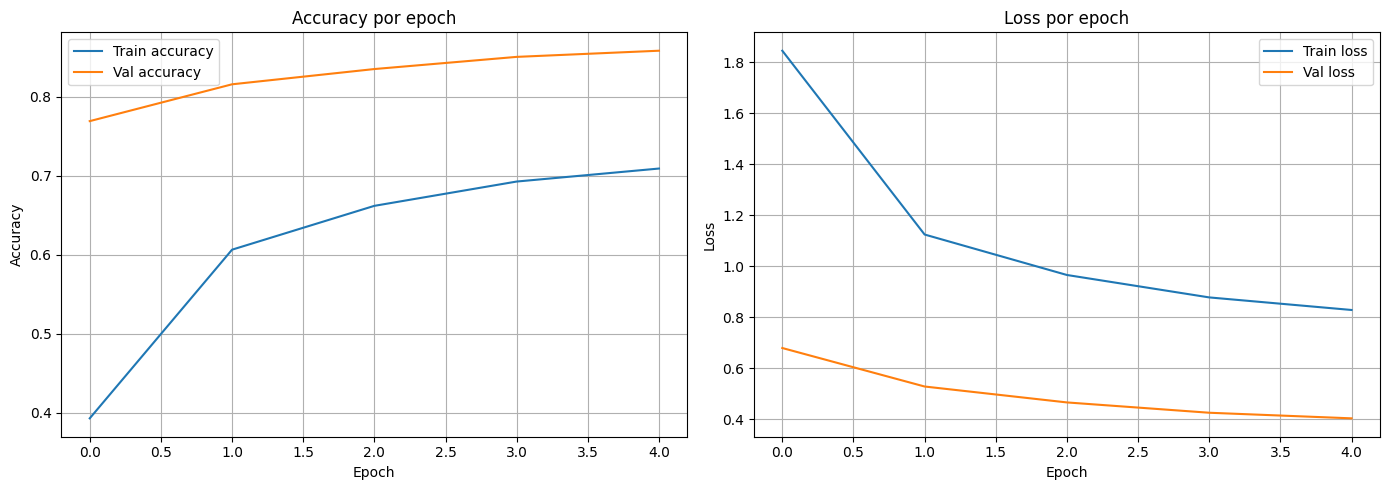

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafica de accuracy
axes[0].plot(history.history['accuracy'],     label='Train accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val accuracy')
axes[0].set_title('Accuracy por epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Grafica de loss
axes[1].plot(history.history['loss'],     label='Train loss')
axes[1].plot(history.history['val_loss'], label='Val loss')
axes[1].set_title('Loss por epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Evaluación final sobre el conjunto de test

Se mide el rendimiento del modelo entrenado sobre datos que nunca vio durante
el entrenamiento ni la validación. Estas métricas son las más representativas
del comportamiento real del modelo.

In [10]:
# Evaluar el modelo sobre el conjunto de test
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 134ms/step - accuracy: 0.9386 - loss: 0.1838
Test loss     : 0.1838
Test accuracy : 0.9386


## Reporte de clasificación por categoría

Se analiza el desempeño por clase mediante precisión, recall y F1-score.
Esto permite identificar qué categorías son más difíciles de clasificar
y si existe desbalance en los errores.

In [14]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Generar el reporte de clasificación
report = classification_report(y_test, y_pred_classes, target_names=CLASS_NAMES)
print("\nReporte de clasificación por categoría:")
print(report)

313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 136ms/step

Reporte de clasificación por categoría:
              precision    recall  f1-score   support

    airplane       0.96      0.94      0.95      1000
  automobile       0.94      0.98      0.96      1000
        bird       0.95      0.93      0.94      1000
         cat       0.93      0.83      0.88      1000
        deer       0.93      0.94      0.93      1000
         dog       0.88      0.93      0.91      1000
        frog       0.94      0.98      0.96      1000
       horse       0.95      0.95      0.95      1000
        ship       0.96      0.95      0.96      1000
       truck       0.95      0.96      0.95      1000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000

